In [38]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading and Merging

In [39]:
df = pd.read_csv('./data/partidos.csv')
df_ranking = pd.read_csv('./data/ranking_fifa.csv')
df_transfermarkt = pd.read_csv('./data/transfermarkt.csv')

/var/folders/2b/bj2_4__51r32s3w8hq5kns5r0000gn/T/ipykernel_30403/1432938540.py:1: DtypeWarning: Columns (0: Pases_largos_Local, 1: Pases_largos_Visitante, 2: Pases_en_el_tercio_final_Local, 3: Pases_en_el_tercio_final_Visitante, 4: Centros_Local, 5: Centros_Visitante, 6: Entradas_Local, 7: Entradas_Visitante, 8: 2Córneres2_Local, 9: 2Córneres2_Visitante, 10: 2Córneres3_Local, 11: 2Córneres3_Visitante, 12: 4Córneres4_Local, 13: 4Córneres4_Visitante, 14: 0Córneres8_Local, 15: 0Córneres8_Visitante, 16: 3Córneres1_Local, 17: 3Córneres1_Visitante, 18: 5Córneres6_Local, 19: 5Córneres6_Visitante, 20: 3Córneres6_Local, 21: 3Córneres6_Visitante, 22: Gol1_-_0_Local, 23: Gol1_-_0_Visitante, 24: 1_-_1Gol_Local, 25: 1_-_1Gol_Visitante, 26: Sustitución_-_Entra_Local, 27: Sustitución_-_Entra_Visitante, 28: 1_-_2Gol_Local, 29: 1_-_2Gol_Visitante, 30: 2Córneres16_Local, 31: 2Córneres16_Visitante, 32: 7Córneres5_Local, 33: 7Córneres5_Visitante, 34: 5Córneres4_Local, 35: 5Córneres4_Visitante, 36: 0_-_2Go

In [40]:
# first we changed to english our original variables that were in spanish
rename_data_matches = {
    'Fecha': 'Date',
    'Equipo_Local': 'Home_Team',
    'Equipo_Visitante': 'Away_Team',
    'Resultado': 'Result',
    'Goles_esperados_(xG)_Local': 'Expected_Goals_Home_(xG)',
    'Goles_esperados_(xG)_Visitante': 'Expected_Goals_Away_(xG)',
    'Posesión_Local': 'Possession_Home',
    'Posesión_Visitante': 'Possession_Away',
    'Remates_totales_Local': 'Total_Shots_Home',
    'Remates_totales_Visitante': 'Total_Shots_Away',
    'Remates_a_puerta_Local': 'Shots_on_Target_Home',
    'Remates_a_puerta_Visitante': 'Shots_on_Target_Away',
    'Remates_fuera_Local': 'Shots_Off_Target_Home',
    'Remates_fuera_Visitante': 'Shots_Off_Target_Away',
    'Remates_rechazados_Local': 'Blocked_Shots_Home',
    'Remates_rechazados_Visitante': 'Blocked_Shots_Away',
    'Córneres_Local': 'Corners_Home',
    'Córneres_Visitante': 'Corners_Away',
    'Pases_Local': 'Passes_Home',
    'Pases_Visitante': 'Passes_Away',
    'Tarjetas_amarillas_Local': 'Yellow_Cards_Home',
    'Tarjetas_amarillas_Visitante': 'Yellow_Cards_Away',
    'Fueras_de_juego_Local': 'Offsides_Home',
    'Fueras_de_juego_Visitante': 'Offsides_Away',
    'Tiros_libres_Local': 'Free_Kicks_Home',
    'Tiros_libres_Visitante': 'Free_Kicks_Away',
    'Saques_de_banda_Local': 'Throw_Ins_Home',
    'Saques_de_banda_Visitante': 'Throw_Ins_Away',
    'Faltas_Local': 'Fouls_Home',
    'Faltas_Visitante': 'Fouls_Away',
    'Paradas_Local': 'Saves_Home',
    'Paradas_Visitante': 'Saves_Away',
    'Anuncio_Local': 'Announcement_Home',
    'Anuncio_Visitante': 'Announcement_Away',
    'checkbox_label_label_Local': 'Checkbox_Label_Home',
    'checkbox_label_label_Visitante': 'Checkbox_Label_Away',
}

rename_ranking = {
    'País': 'Country',
    'Puntuación': 'Score',
    'Fecha': 'Date',
}

rename_transfermarkt = {
    'Equipo': 'Team',
    'Valor_Mercado_Millones_Eur': 'Market_Value_Millions_EUR',
}

df.rename(columns=rename_data_matches, inplace=True)
df_ranking.rename(columns=rename_ranking, inplace=True)
df_transfermarkt.rename(columns=rename_transfermarkt, inplace=True)

In [41]:
df.columns

Index(['Unnamed: 0', 'Date', 'URL', 'Home_Team', 'Away_Team', 'Result',
       'Expected_Goals_Home_(xG)', 'Expected_Goals_Away_(xG)',
       'Possession_Home', 'Possession_Away',
       ...
       '84%(410/486)Pases79%(328/417)_Local',
       '84%(410/486)Pases79%(328/417)_Visitante', '5Faltas11_Local',
       '5Faltas11_Visitante', '73%(263/360)Pases74%(264/359)_Local',
       '73%(263/360)Pases74%(264/359)_Visitante',
       '82%(347/422)Pases86%(431/501)_Local',
       '82%(347/422)Pases86%(431/501)_Visitante',
       '68%(282/413)Pases58%(180/308)_Local',
       '68%(282/413)Pases58%(180/308)_Visitante'],
      dtype='str', length=2778)

In [42]:
# check no duplicates
print(df.shape)
df.drop_duplicates(subset=['URL', 'Date', 'Home_Team', 'Away_Team'], keep='last', inplace=True)
print(df.shape)

(3316, 2778)
(3316, 2778)


## Dataset Overview

Summary of the raw dataset after deduplication: shape, variable type and temporal coverage.

In [43]:
# Table 1: Raw dataset summary 
print(f'Shape: {df.shape[0]} matches x {df.shape[1]} variables')
print(f'Temporal range: {df["Date"].min()} - {df["Date"].max()}')

tipos = df.dtypes.value_counts()
print('\nTable 1. Variable types in raw dataset')
for t, n in tipos.items():
    print(f'  {str(t):15s}: {n} columns')

print(f'\nTotal missing values: {df.isna().sum().sum():,}')
print(f'Overall missing rate: {df.isna().mean().mean():.1%}')


Shape: 3316 matches x 2778 variables
Temporal range: 01.01.2026 14:00 - 31.12.2025 20:00

Table 1. Variable types in raw dataset
  str            : 2720 columns
  float64        : 57 columns
  int64          : 1 columns

Total missing values: 9,090,640
Overall missing rate: 98.7%


### All Matches

For the new research question (*Which performance statistics predict the match outcome?*), we keep all available matches without filtering by World Cup teams.


In [44]:
print(df.shape)

(3316, 2778)


## Join ranking FIFA

We will create a dictionary to join the FlashScore data with the FIFA ranking.


In [45]:
# KEY = Name in df_ranking (the one we want to change)
# VALUE = Name in df_partidos (the one we want to keep)
# Country names are kept in Spanish on purpose because these are raw values from the sources and changing them would break the join.
country_name_mapping = {
    'EEUU': 'EE. UU.',
    'RI de Irán': 'Irán',
    'República de Corea': 'Corea del Sur',
    'RD del Congo': 'RD Congo',
    'Bosnia y Herzegovina': 'Bosnia-Herzegovina',
    'Baréin': 'Bahréin',
    'RP China': 'China',
    'República Kirguisa': 'Kirguistán',
    'Kazajstán': 'Kazajistán',
    'RDP de Corea': 'Corea del Norte',
    'Guinea-Bissáu': 'Guinea-Bisáu',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Hong Kong, China': 'Hong Kong',
    'Myanmar': 'Birmania',
    'Esuatini': 'Eswatini',
    'Chinese Taipei': 'China Taipei',
    'Bangladesh': 'Bangladés',
    'Samoa Estadounidense': 'Samoa Americana',
    'Brunéi Darussalam': 'Brunéi',
    'República de Irlanda': 'Irlanda',
    'Qatar': 'Catar',
    'Turcas y Caicos': 'Islas Turcas y Caicos',
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'Comoras': 'Comores'
}

# Apply the replacement to the df_ranking column
df_ranking['Country'] = df_ranking['Country'].replace(country_name_mapping)

# Check if any country is unmatched
country_df = set(df['Home_Team'].unique()).union(set(df['Away_Team'].unique()))
country_ranking = set(df_ranking['Country'].unique())
orphan = country_df - country_ranking

if orphan:
    print(f"WARNING: {len(orphan)} countries have NO associated FIFA ranking:")
    print(sorted(list(orphan)))
else:
    print(" All countries in your matches have an exact match in the FIFA ranking.")


['Afganistán Sub-20', 'Albania Sub-21', 'Alemania Sub-17', 'Alemania Sub-18', 'Alemania Sub-19', 'Arabia Saudí Sub-20', 'Argelia Sub-20', 'Argelia Sub-23', 'Argentina Sub-17', 'Argentina Sub-20', 'Australia Sub-17', 'Australia Sub-20', 'Austria Sub-17', 'Austria Sub-18', 'Bonaire', 'Bosnia-Herzegovina Sub-19', 'Brasil Sub-20', 'Bulgaria Sub-19', 'Bután Sub-23', 'Bélgica Sub-17', 'Bélgica Sub-21', 'Catar Sub-17', 'Catar Sub-20', 'Catar Sub-23', 'Chile Sub-17', 'Chile Sub-20', 'China Sub-20', 'China Sub-23', 'Chipre Sub-19', 'Colombia Sub-20', 'Corea del Norte Sub-23', 'Corea del Sur Sub-17', 'Corea del Sur Sub-23', 'Costa Rica Sub-20', 'Costa de Marfil Sub-20', 'Costa de Marfil Sub-23', 'Croacia Sub-17', 'Croacia Sub-19', 'EE. UU. Sub-18', 'EE. UU. Sub-19', 'EE. UU. Sub-20', 'EE. UU. Sub-21', 'Ecuador Sub-17', 'Egipto Sub-19', 'Egipto Sub-20', 'Emiratos Árabes Unidos Sub-19', 'Emiratos Árabes Unidos Sub-20', 'Emiratos Árabes Unidos Sub-23', 'Escocia Sub-17', 'Eslovaquia Sub-18', 'Eslova

In [46]:
print(df_ranking.head())

      Country    Score        Date
0     Francia  1877.32  01-04-2026
1      España  1876.40  01-04-2026
2   Argentina  1874.81  01-04-2026
3  Inglaterra  1825.97  01-04-2026
4    Portugal  1763.83  01-04-2026


We unify the date formats for the JOIN.


In [47]:
# Date handling
# Convert the column to Pandas datetime format, recognising dots and time
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y %H:%M')

# If the time is not needed, keep only the clean date (YYYY-MM-DD)
df['Date'] = df['Date'].dt.normalize()

# Change the date format to YYYY-MM-DD
df_ranking['Date'] = pd.to_datetime(df_ranking['Date'], format='%d-%m-%Y')
df_ranking['Date'] = pd.to_datetime(df_ranking['Date']).dt.strftime('%Y-%m-%d')

# Force both columns to pure datetime
df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
df_ranking['Date'] = pd.to_datetime(df_ranking['Date']).dt.tz_localize(None)


In [48]:
# SORT by date (required for merge_asof)
df = df.sort_values('Date').reset_index(drop=True)
df_ranking = df_ranking.sort_values('Date').reset_index(drop=True)

# 1. Merge ranking for the HOME TEAM
df = pd.merge_asof(
    df, 
    df_ranking,
    on='Date',   
    left_by='Home_Team',   
    right_by='Country',          
    direction='backward',     
    allow_exact_matches=False 
)

df = df.rename(columns={
    'Score': 'Home_Score'  
})

# 2. Merge ranking for the AWAY TEAM
df = pd.merge_asof(
    df, 
    df_ranking,
    on='Date',       
    left_by='Away_Team',
    right_by='Country',
    direction='backward',
    allow_exact_matches=False 
) 

# Rename the away team data
df = df.rename(columns={
    'Score': 'Away_Score'
})

#  The Country column from df_ranking will appear twice, so we clean it up
columnas_a_borrar = [col for col in df.columns if 'Country' in col]
print(columnas_a_borrar)
df = df.drop(columns=columnas_a_borrar)

# Check the JOIN
print(df[['Date', 'Home_Team', 'Home_Score', 'Away_Team', 'Away_Score']].head())


['Country_x', 'Country_y']
        Date Home_Team  Home_Score  Away_Team  Away_Score
0 2019-06-06  Mongolia       915.0     Brunéi       903.0
1 2019-06-06     Macao       925.0  Sri Lanka       886.0
2 2019-06-06      Laos       923.0  Bangladés       907.0
3 2019-06-06   Camboya       970.0   Pakistán       888.0
4 2019-06-06     Bután       917.0       Guam       907.0


## Join Market Value


In [49]:
df_transfermarkt.head()

,Team,Market_Value_Millions_EUR
0,Francia,58.58
1,Inglaterra,52.43
2,España,47.03
3,Portugal,38.67
4,Alemania,36.42


In [50]:
dic_Transfermarkt = {
    'Estados Unidos': 'EE. UU.',
    'Chequia': 'República Checa',
    'República Democrática del Congo': 'RD Congo',
    'Arabia Saudita': 'Arabia Saudí',
    'Malí': 'Mali',
    'Comoras': 'Comores',
    'Baréin': 'Bahréin',
    'Myanmar': 'Birmania',
    'República del Congo': 'Congo',
    'China Taipéi': 'China Taipei',
    'Esuatini': 'Eswatini',
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Brunéi Darussalam': 'Brunéi',
    'Islas Vírgenes de los Estados Unidos': 'Islas Vírgenes Estadounidenses'
}

df_transfermarkt['Team'] = df_transfermarkt['Team'].replace(dic_Transfermarkt)


In [51]:
# 1.Merge market value for the HOME TEAM
df = pd.merge(
    df, 
    df_transfermarkt,        
    left_on='Home_Team',   
    right_on='Team',       
    how='left'               
)

# Renaming the home value column and dropping the redundant Team column
df = df.rename(columns={
    'Market_Value_Millions_EUR': 'Home_Market_Value_Millions_EUR'  
}).drop(columns=['Team'])

# 2. Merge market value for the AWAY TEAM
df = pd.merge(
    df, 
    df_transfermarkt,        
    left_on='Away_Team', 
    right_on='Team',     
    how='left'
)

df = df.rename(columns={
    'Market_Value_Millions_EUR': 'Away_Market_Value_Millions_EUR'
}).drop(columns=['Team'])

# Check the JOIN
print(df[['Date', 'Home_Team', 'Home_Market_Value_Millions_EUR', 'Away_Team', 'Away_Market_Value_Millions_EUR']].head())

        Date Home_Team  Home_Market_Value_Millions_EUR  Away_Team  \
0 2019-06-06  Mongolia                           0.024     Brunéi   
1 2019-06-06     Macao                           0.016  Sri Lanka   
2 2019-06-06      Laos                           0.057  Bangladés   
3 2019-06-06   Camboya                           0.099   Pakistán   
4 2019-06-06     Bután                           0.037       Guam   

   Away_Market_Value_Millions_EUR  
0                           0.035  
1                           0.040  
2                           0.315  
3                           0.154  
4                           0.010  


## Continent Data

We group countries by continent so we can use this variable in modelling (facing teams from Africa is not the same as facing teams from Europe).


In [52]:
map_continents = {
    # EUROPE (UEFA)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa',
    
    # SOUTH AMERICA (CONMEBOL)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',
    
    # NORTH AMERICA AND CARIBBEAN (CONCACAF)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',
    
    # AFRICA (CAF)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa',
    
    # ASIA (AFC) - Note: Australia competes in Asia
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia'
}

In [53]:
# Apply the dictionary to create the new columns
df['Home_Continent'] = df['Home_Team'].map(map_continents)
df['Away_Continent'] = df['Away_Team'].map(map_continents)

In [54]:
print(df['Home_Continent'].value_counts())

Home_Continent
Europa          416
Asia            218
Africa          171
Sudamérica      151
Norteamérica    119
Name: count, dtype: int64


# Data Cleaning

In [55]:
print(df.shape)
# we want rows that do NOT  contain 'sub' (to remove U20, U17, etc)
# we use na=False to avoid errors when a cell is empty
local_filter = ~df['Home_Team'].astype(str).str.contains('sub', case=False, na=False)
away_filter = ~df['Away_Team'].astype(str).str.contains('sub', case=False, na=False)

# both conditions together
df = df[local_filter & away_filter]

# reset index to be sequential after dropping rows
df = df.reset_index(drop=True)
print(df.shape)
df.head()


(3316, 2784)
(3144, 2784)


,Unnamed: 0,Date,URL,Home_Team,Away_Team,Result,Expected_Goals_Home_(xG),Expected_Goals_Away_(xG),Possession_Home,Possession_Away,...,82%(347/422)Pases86%(431/501)_Local,82%(347/422)Pases86%(431/501)_Visitante,68%(282/413)Pases58%(180/308)_Local,68%(282/413)Pases58%(180/308)_Visitante,Home_Score,Away_Score,Home_Market_Value_Millions_EUR,Away_Market_Value_Millions_EUR,Home_Continent,Away_Continent
0,2542,2019-06-06,https://www.flashscore.es/partido/futbol/brune...,Mongolia,Brunéi,2-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,915.0,903.0,0.024,0.035,NaN,NaN
1,2541,2019-06-06,https://www.flashscore.es/partido/futbol/macao...,Macao,Sri Lanka,1-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,925.0,886.0,0.016,0.040,NaN,NaN
2,2540,2019-06-06,https://www.flashscore.es/partido/futbol/bangl...,Laos,Bangladés,0-1Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,923.0,907.0,0.057,0.315,NaN,NaN
3,2539,2019-06-06,https://www.flashscore.es/partido/futbol/cambo...,Camboya,Pakistán,2-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,970.0,888.0,0.099,0.154,NaN,NaN
4,2538,2019-06-06,https://www.flashscore.es/partido/futbol/butan...,Bután,Guam,1-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,917.0,907.0,0.037,0.010,NaN,NaN


The scraper has downloaded many variables, some of which we do not want to use because they are poorly populated or assumed to have low predictive power, so we remove them. We also drop columns that are not relevant and some variables that are highly correlated with others like for example Total_Shots_Home and Shots_on_Target_Away.


In [56]:
# identifying highly correlated variables (above 0.7) to consider dropping them
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.7)
]



In [57]:
na_pct = df.isna().mean().sort_values(ascending=False) * 100
print(len(na_pct[na_pct > 50]))
print(len(na_pct))

#keep these two metrics for their explanatory power and because they are not highly correlated with other features
col_keep = ['Expected_Goals_Home_(xG)', 'Expected_Goals_Away_(xG)']

col_delete = [
    c for c in df.columns 
    if c not in col_keep          
    and df[c].isna().mean() > 0.5        
]

df = df.drop(columns=col_delete)
print(df.shape[1])


2744
2784
42


**Figure 1.** Percentage of missing values per variable in the raw dataset (after all joins, before column selection). The dashed line marks the 50% threshold used to drop uninformative variables.

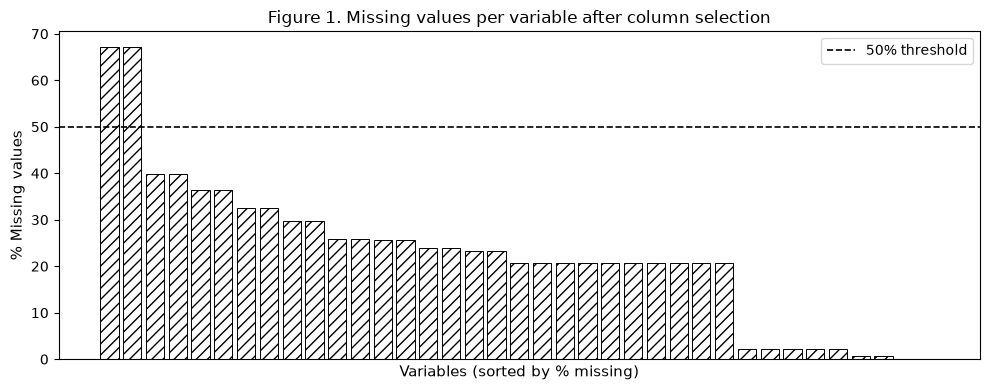

Variables with >50% NaN (protected variables): 2
Variables with any NaN: 37
Complete variables (0% NaN): 5


In [58]:
#  Figure 1: Missing data before cleaning 
na_pct_raw = df.isna().mean().sort_values(ascending=False) * 100
na_with_values = na_pct_raw[na_pct_raw > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(na_with_values)), na_with_values.values,
              color='white', edgecolor='black', linewidth=0.7)
for bar in bars:
    bar.set_hatch('///')
ax.axhline(50, color='black', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_xlabel('Variables (sorted by % missing)', fontsize=11)
ax.set_ylabel('% Missing values', fontsize=11)
ax.set_title('Figure 1. Missing values per variable after column selection', fontsize=12)
ax.set_xticks([])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Variables with >50% NaN (protected variables): {(na_pct_raw > 50).sum()}')
print(f'Variables with any NaN: {(na_pct_raw > 0).sum()}')
print(f'Complete variables (0% NaN): {(na_pct_raw == 0).sum()}')

In [62]:
# Define the strict list of variables for the model
# We removed those with more than 50% missing values
# We also identified those highly correlated with other variables
# We handle this by defining the following list, which omits several features
columns = [
    'Date', 'Home_Team', 'Away_Team', 'Result', 
    'Expected_Goals_Home_(xG)', 'Expected_Goals_Away_(xG)', 
    'Possession_Home', 'Possession_Away', 
    'Shots_on_Target_Home', 'Shots_on_Target_Away', 
    'Corners_Home', 'Corners_Away', 
    'Passes_Home', 'Passes_Away', 
    'Yellow_Cards_Home', 'Yellow_Cards_Away',
    'Fouls_Home', 'Fouls_Away', 
    'Saves_Home', 'Saves_Away',
    'Home_Score', 'Away_Score',
    'Home_Market_Value_Millions_EUR', 'Away_Market_Value_Millions_EUR'
]

# Filter using list comprehension
existing_columns = [col for col in columns if col in df.columns]

# Overwrite the DataFrame with the validated subset
df = df[existing_columns]


In [63]:
# resulting dataset
pd.set_option('display.max_columns', None)
print(df.shape)
df.head()
df.describe()


(3144, 24)


,Date,Expected_Goals_Home_(xG),Expected_Goals_Away_(xG),Shots_on_Target_Home,Shots_on_Target_Away,Corners_Home,Corners_Away,Yellow_Cards_Home,Yellow_Cards_Away,Fouls_Home,Fouls_Away,Saves_Home,Saves_Away,Home_Score,Away_Score,Home_Market_Value_Millions_EUR,Away_Market_Value_Millions_EUR
count,3144,1032.000000,1032.000000,2495.000000,2495.000000,2495.000000,2495.000000,2390.000000,2390.000000,2328.000000,2328.000000,2411.000000,2411.000000,3122.000000,3121.000000,3141.000000,3140.000000
mean,2023-09-28 15:34:21.068702,1.464564,1.125388,4.490982,3.647695,4.989980,4.030461,1.841841,2.054393,12.225086,12.278780,2.479469,2.973455,1330.970368,1321.980381,6.665954,6.212583
min,2019-06-06 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,726.030000,727.950000,0.000000,0.000000
25%,2022-01-30 00:00:00,0.670000,0.450000,2.000000,2.000000,3.000000,2.000000,1.000000,1.000000,9.000000,9.000000,1.000000,1.000000,1140.142500,1135.420000,0.297000,0.285000
50%,2024-03-21 00:00:00,1.250000,0.930000,4.000000,3.000000,4.000000,4.000000,2.000000,2.000000,12.000000,12.000000,2.000000,3.000000,1343.385000,1334.370000,1.380000,1.330000
75%,2025-03-20 00:00:00,2.030000,1.530000,6.000000,5.000000,7.000000,6.000000,3.000000,3.000000,15.000000,15.000000,4.000000,4.000000,1511.135000,1500.520000,7.640000,7.405000
max,2026-06-28 00:00:00,9.570000,6.340000,22.000000,25.000000,20.000000,20.000000,7.000000,11.000000,33.000000,37.000000,14.000000,15.000000,1901.480000,1901.480000,58.580000,58.580000
std,NaN,1.072548,0.898599,3.105957,2.713189,3.278001,2.895098,1.338207,1.392879,4.408456,4.513365,2.028401,2.245909,253.908292,248.866940,11.295491,10.847050


Data such as xG is not available for very old dates, so we keep only matches with more recent dates.


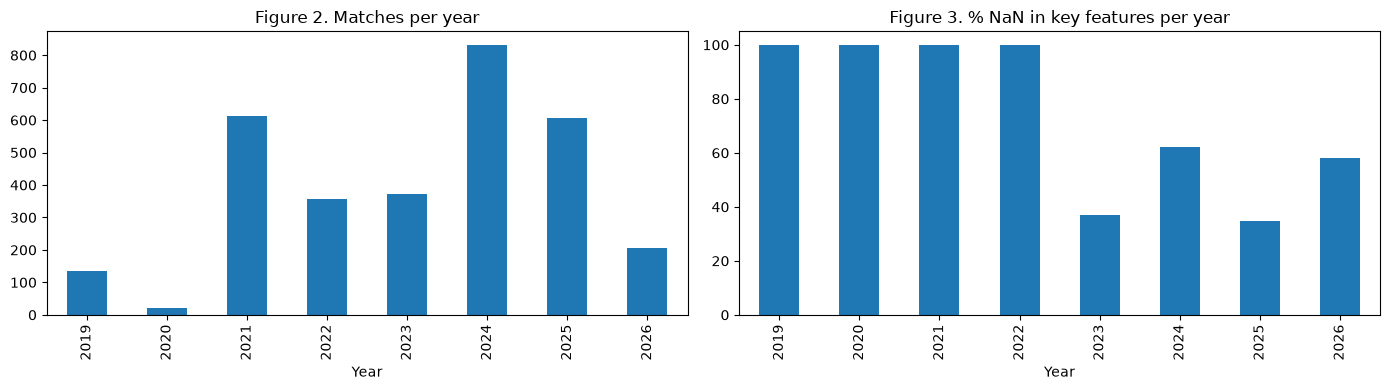

In [64]:
import matplotlib.pyplot as plt

# Matches per year
df['Year'] = df['Date'].dt.year
conteo = df.groupby('Year').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Match volume per year
conteo.plot(kind='bar', ax=axes[0], title='Figure 2. Matches per year')

# % of NaN in key features per year (the actual justification)
features_clave = ['Expected_Goals_Home_(xG)', 'Expected_Goals_Away_(xG)']  # add xG or other features if available
pct_nans = df.groupby('Year')[features_clave].apply(lambda x: x.isna().mean().mean() * 100)
pct_nans.plot(kind='bar', ax=axes[1], title='Figure 3. % NaN in key features per year')

plt.tight_layout()
plt.show()


In [ ]:
# Remove very old dates because theres little information available
threshold_date = pd.to_datetime('2023-01-01')
df = df[df['Date'] >= threshold_date].copy()
print(df.shape)
df.head()


(2017, 25)


,Date,Home_Team,Away_Team,Result,Expected_Goals_Home_(xG),Expected_Goals_Away_(xG),Possession_Home,Possession_Away,Shots_on_Target_Home,Shots_on_Target_Away,Corners_Home,Corners_Away,Passes_Home,Passes_Away,Yellow_Cards_Home,Yellow_Cards_Away,Fouls_Home,Fouls_Away,Saves_Home,Saves_Away,Home_Score,Away_Score,Home_Market_Value_Millions_EUR,Away_Market_Value_Millions_EUR,Year
1127,2023-03-23,Portugal,Liechtenstein,4-0Finalizado,4.16,0.03,71%,29%,11.0,1.0,12.0,0.0,91%(677/740),56%(91/162),NaN,NaN,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023
1128,2023-03-23,San Marino,Irlanda del Norte,0-2Finalizado,0.03,1.79,30%,70%,1.0,4.0,0.0,9.0,71%(205/287),87%(582/668),0.0,1.0,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023
1129,2023-03-23,Kazajistán,Eslovenia,1-2Finalizado,0.63,1.49,43%,57%,2.0,6.0,3.0,4.0,75%(225/301),86%(408/474),2.0,1.0,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023
1130,2023-03-23,Eslovaquia,Luxemburgo,0-0Finalizado,1.25,0.61,48%,52%,3.0,2.0,9.0,2.0,80%(321/401),78%(334/428),0.0,2.0,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023
1131,2023-03-23,Italia,Inglaterra,1-2Finalizado,1.16,2.07,49%,51%,1.0,4.0,7.0,3.0,81%(420/516),82%(318/389),3.0,5.0,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023


## Feature Engineering

Some variables come in unusual formats after scraping. For example, Passes_Home comes as 91%(814/897). We will extract the individual values to create usable variables for modelling.


### Cleaning the Result Variable


In [66]:
def clean_flashcore_results(text):
    text = str(text).strip()
    
    # if the match was decided in 90 minutes (e.g. "2-1Finalizado")
    match_fin = re.match(r'^(\d+-\d+)\s*Finalizado', text)
    if match_fin:
        result_90  = match_fin.group(1)
        return pd.Series([result_90 , None, None])
        
    # if the match was decided in extra time (e.g. "1-0(0-0)Tras la prórroga")
    # We capture 1-0 as the final score and 0-0 as the regular-time score
    match_pro = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras la prórroga', text)
    if match_pro:
        result_120 = match_pro.group(1) # Final score after 120 min (1-0)
        result_90  = match_pro.group(2)  # Score at 90 min (0-0)
        
        # FIX: We assign the draw (0-0) as the main 90-min result
        # and store 1-0 in the extra time column
        return pd.Series([result_90 , result_120, None])
        
    # if the match decided on penalties (e.g. "2-1(1-1)Tras los penaltis")
    match_pen = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras los penaltis', text)
    if match_pen:
        result_penaltis = match_pen.group(1) # Penalty shootout result (2-1)
        result_120 = match_pen.group(2)      # Match score after 120 min (1-1)
        
        # We assign the draw (1-1) as the main result since both stages ended in a draw
        return pd.Series([result_120, result_120, result_penaltis])
    
    # if match lost by walkover (e.g. "0-3Por perdido")
    match_walkover = re.match(r'^(\d+-\d+)\s*Por perdido', text)
    if match_walkover:
        return pd.Series([match_walkover.group(1), None, None])    

    # Residual case (postponed, suspended, or other formats)
    return pd.Series([text, None, None])


new_col = ['Result', 'Extra_Time_Result', 'Penalty_Shootout_Result']
df[new_col] = df['Result'].apply(clean_flashcore_results)
print(len(df))
print(df['Result'].isna().sum())
print(df[['Result', 'Extra_Time_Result', 'Penalty_Shootout_Result']].head())
print(df['Penalty_Shootout_Result'].notna().sum(), "matches decided on penalties")
print(df['Extra_Time_Result'].notna().sum(), "matches with extra time")
print(df['Result'].isna().sum(), "results not parsed (residual case)")

2017
0
     Result Extra_Time_Result Penalty_Shootout_Result
1127    4-0               NaN                     NaN
1128    0-2               NaN                     NaN
1129    1-2               NaN                     NaN
1130    0-0               NaN                     NaN
1131    1-2               NaN                     NaN
30 matches decided on penalties
42 matches with extra time
0 results not parsed (residual case)


### Cleaning Variables with (%)


In [67]:
# only columns that have this format
combined_cols = ['Passes_Home', 'Passes_Away'] 

for col in combined_cols:
    extraction = df[col].astype(str).str.extract(r'(\d+)%\((\d+)/\d+\)')
    
    # two new columns from the extraction and to numeric.
    df[f"{col}_Pct"] = pd.to_numeric(extraction[0], errors='coerce')
    df[f"{col}_Successful"] = pd.to_numeric(extraction[1], errors='coerce')

# check the result and drop the original column
print(df[[f"{combined_cols[0]}_Pct", f"{combined_cols[0]}_Successful"]].head())

df = df.drop(columns=combined_cols) 


      Passes_Home_Pct  Passes_Home_Successful
1127             91.0                   677.0
1128             71.0                   205.0
1129             75.0                   225.0
1130             80.0                   321.0
1131             81.0                   420.0


In [68]:
percentaje_cols = ['Possession_Home', 'Possession_Away', 'Passes_Home_Pct', 'Passes_Away_Pct'] 

for col in percentaje_cols:
    df[col] = df[col].astype(str).str.replace('%', '').astype(float) 

print(df[['Possession_Home', 'Possession_Away']].head())


      Possession_Home  Possession_Away
1127             71.0             29.0
1128             30.0             70.0
1129             43.0             57.0
1130             48.0             52.0
1131             49.0             51.0


## Temporal Filter

We remove the 2026 World Cup matches (which are test data, not training data) and keep only the prior historical data for analysis.


In [69]:
print(f"Total original rows: {len(df)}")

# only matches before the 2026 World Cup
threshold_date = pd.to_datetime('2026-06-11')
df = df[df['Date'] < threshold_date].copy()

print(f"Rows for analysis: {len(df)}")


Total original rows: 2017
Rows for analysis: 1945


## Checking Missing Values


In [70]:
df.isnull().sum()

Date                                 0
Home_Team                            0
Away_Team                            0
Result                               0
Expected_Goals_Home_(xG)           913
Expected_Goals_Away_(xG)           913
Possession_Home                    317
Possession_Away                    317
Shots_on_Target_Home               316
Shots_on_Target_Away               316
Corners_Home                       316
Corners_Away                       316
Yellow_Cards_Home                  386
Yellow_Cards_Away                  386
Fouls_Home                         369
Fouls_Away                         369
Saves_Home                         400
Saves_Away                         400
Home_Score                          21
Away_Score                          22
Home_Market_Value_Millions_EUR       3
Away_Market_Value_Millions_EUR       4
Year                                 0
Extra_Time_Result                 1903
Penalty_Shootout_Result           1915
Passes_Home_Pct          

We use the Possession variable to remove rows with NAs. This is because possession is the most basic match statistic. If this data is missing, we assume there is not enough useful information to model the match and we therefore drop those observations.


In [71]:
# Columns that MUST be complete
necessary_cols = ['Possession_Away', 'Possession_Home'] 

# dropping rows that have at least one NA in the required columns
df = df.dropna(subset=necessary_cols)

# now we reset the index after dropping rows
df = df.reset_index(drop=True)

print(df.shape)
df.isnull().sum()


(1628, 29)


Date                                 0
Home_Team                            0
Away_Team                            0
Result                               0
Expected_Goals_Home_(xG)           596
Expected_Goals_Away_(xG)           596
Possession_Home                      0
Possession_Away                      0
Shots_on_Target_Home                 0
Shots_on_Target_Away                 0
Corners_Home                         0
Corners_Away                         0
Yellow_Cards_Home                   71
Yellow_Cards_Away                   71
Fouls_Home                          53
Fouls_Away                          53
Saves_Home                          84
Saves_Away                          84
Home_Score                           7
Away_Score                           8
Home_Market_Value_Millions_EUR       0
Away_Market_Value_Millions_EUR       0
Year                                 0
Extra_Time_Result                 1589
Penalty_Shootout_Result           1600
Passes_Home_Pct          

# Data Imputation

To avoid losing too many observations, we impute missing values using IterativeImputer from sklearn.

The parameters are not fully optimised and the goal here is simply to obtain a complete and reasonable dataset, not a perfect one.


In [72]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Split the dataset, untouchable columns (text/identifiers) and columns to impute
col_text = ['Date', 'Home_Team', 'Away_Team', 'Result', 'Extra_Time_Result', 'Penalty_Shootout_Result'] 
col_numeric = [col for col in df.columns if col not in col_text]

# 2. Set up the Imputer
# We use RandomForest internally because it captures non-linear relationships in football very well
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42,
    min_value=0  # No one can have -2 shots or -0.5 xG
)

# 3. Fit and apply the imputation only on numerical variables
df_imputated = pd.DataFrame(
    imputer.fit_transform(df[col_numeric]), 
    columns=col_numeric, 
    index=df.index
)

# 4. Rejoin the untouched text columns with the cleaned numerical ones
df = pd.concat([df[col_text], df_imputated], axis=1)

print(df.isna().sum())


Date                                 0
Home_Team                            0
Away_Team                            0
Result                               0
Extra_Time_Result                 1589
Penalty_Shootout_Result           1600
Expected_Goals_Home_(xG)             0
Expected_Goals_Away_(xG)             0
Possession_Home                      0
Possession_Away                      0
Shots_on_Target_Home                 0
Shots_on_Target_Away                 0
Corners_Home                         0
Corners_Away                         0
Yellow_Cards_Home                    0
Yellow_Cards_Away                    0
Fouls_Home                           0
Fouls_Away                           0
Saves_Home                           0
Saves_Away                           0
Home_Score                           0
Away_Score                           0
Home_Market_Value_Millions_EUR       0
Away_Market_Value_Millions_EUR       0
Year                                 0
Passes_Home_Pct          

/Users/marta/Documents/GitHub/Football-scrapping-project/venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


We build variables.


In [73]:
df[["Goals_Home", "Goals_Away"]] = df["Result"].str.split("-", expand=True)
df["Goals_Home"] = pd.to_numeric(df["Goals_Home"], errors="coerce")
df["Goals_Away"] = pd.to_numeric(df["Goals_Away"], errors="coerce")

# Multi-class target: 1=Home wins, X=Draw, 2=Away wins
df["Result_1X2"] = df.apply(lambda row: "1" if row["Goals_Home"] > row["Goals_Away"] 
                                         else ("X" if row["Goals_Home"] == row["Goals_Away"] else "2"), axis=1)

# Continuous target: goal difference (for regression)
df["Goals_diff"] = df["Goals_Home"] - df["Goals_Away"]
# Binary target: home win (1) or not (0)
df["Home_Win"] = (df["Goals_Home"] > df["Goals_Away"]).astype(int)

print(df['Result_1X2'].value_counts())
print(f"Home win rate: {df['Home_Win'].mean():.2%}")
df.head()


Result_1X2
1    705
2    526
X    397
Name: count, dtype: int64
Home win rate: 43.30%


,Date,Home_Team,Away_Team,Result,Extra_Time_Result,Penalty_Shootout_Result,Expected_Goals_Home_(xG),Expected_Goals_Away_(xG),Possession_Home,Possession_Away,Shots_on_Target_Home,Shots_on_Target_Away,Corners_Home,Corners_Away,Yellow_Cards_Home,Yellow_Cards_Away,Fouls_Home,Fouls_Away,Saves_Home,Saves_Away,Home_Score,Away_Score,Home_Market_Value_Millions_EUR,Away_Market_Value_Millions_EUR,Year,Passes_Home_Pct,Passes_Home_Successful,Passes_Away_Pct,Passes_Away_Successful,Goals_Home,Goals_Away,Result_1X2,Goals_diff,Home_Win
0,2023-03-23,Portugal,Liechtenstein,4-0,NaN,NaN,4.16,0.03,71.0,29.0,11.0,1.0,12.0,0.0,0.36,1.32,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023.0,91.0,677.0,56.0,91.0,4,0,1,4,1
1,2023-03-23,San Marino,Irlanda del Norte,0-2,NaN,NaN,0.03,1.79,30.0,70.0,1.0,4.0,0.0,9.0,0.00,1.00,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023.0,71.0,205.0,87.0,582.0,0,2,2,-2,0
2,2023-03-23,Kazajistán,Eslovenia,1-2,NaN,NaN,0.63,1.49,43.0,57.0,2.0,6.0,3.0,4.0,2.00,1.00,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023.0,75.0,225.0,86.0,408.0,1,2,2,-1,0
3,2023-03-23,Eslovaquia,Luxemburgo,0-0,NaN,NaN,1.25,0.61,48.0,52.0,3.0,2.0,9.0,2.0,0.00,2.00,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023.0,80.0,321.0,78.0,334.0,0,0,X,0,0
4,2023-03-23,Italia,Inglaterra,1-2,NaN,NaN,1.16,2.07,49.0,51.0,1.0,4.0,7.0,3.0,3.00,5.00,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023.0,81.0,420.0,82.0,318.0,1,2,2,-1,0


We will build "Share" variables. Essentially, out of the total shots, what percentage belongs to the home team and what percentage to the away team. These variables tend to work very well in sports, as they indicate the offensive power of a team not in absolute terms but relative to the match.


In [75]:
# Structure: (Home Column Name, Away Column Name, Name for the new metric)
metric_pairs = [
    ('Expected_Goals_Home_(xG)', 'Expected_Goals_Away_(xG)', 'xG'),
    ('Shots_on_Target_Home', 'Shots_on_Target_Away', 'Shots_on_Target'),
    ('Corners_Home', 'Corners_Away', 'Corners'),
    ('Saves_Home', 'Saves_Away', 'Saves'),
    ('Passes_Home_Successful', 'Passes_Away_Successful', 'Passes_Successful'),
    ('Goals_Home', 'Goals_Away', 'Goals'),
    ('Home_Score', 'Away_Score', 'Score'),
    ('Home_Market_Value_Millions_EUR', 'Away_Market_Value_Millions_EUR', 'Market_Value_Millions_EUR')
]

for col_local, col_away, base_name in metric_pairs:
    # 1.Calculate  total volume of the metric in the match
    total_sum = df[col_local] + df[col_away]
    
    # 2.Calculate Home Share
    df[f'{base_name}_Share_Home'] = np.where(
        total_sum > 0,
        df[col_local] / total_sum,
        0.5  # Assign 0.5 when total is 0 (for example 0 goals from both = balanced match)
    )
    
    # 3. The Away Share is mathematically the inverse (1 - Home)
    df[f'{base_name}_Share_Away'] = 1 - df[f'{base_name}_Share_Home']

#sample of the newly generated columns
generated_cols = [f"{t[2]}_Share_Home" for t in metric_pairs]

# Check 
df[['Home_Team', 'Away_Team', 'Result'] + generated_cols].head()


,Home_Team,Away_Team,Result,xG_Share_Home,Shots_on_Target_Share_Home,Corners_Share_Home,Saves_Share_Home,Passes_Successful_Share_Home,Goals_Share_Home,Score_Share_Home,Market_Value_Millions_EUR_Share_Home
0,Portugal,Liechtenstein,4-0,0.992840,0.916667,1.000000,0.125000,0.881510,1.000000,0.664437,0.999328
1,San Marino,Irlanda del Norte,0-2,0.016484,0.200000,0.000000,0.666667,0.260483,0.000000,0.353359,0.012521
2,Kazajistán,Eslovenia,1-2,0.297170,0.250000,0.428571,0.800000,0.355450,0.333333,0.455729,0.139555
3,Eslovaquia,Luxemburgo,0-0,0.672043,0.600000,0.818182,0.400000,0.490076,0.500000,0.533739,0.782579
4,Italia,Inglaterra,1-2,0.359133,0.200000,0.700000,1.000000,0.569106,0.333333,0.492762,0.207527


## Raw Statistics Differences (Home - Away)

For the question, the match statistics are our main variables of interest. We create Home − Away differences for each metric so that a positive value indicates a home team advantage.

In [ ]:
metrics_diff = [
    ('Expected_Goals_Home_(xG)', 'Expected_Goals_Away_(xG)', 'xG_diff'),
    ('Possession_Home', 'Possession_Away', 'Possession_diff'),
    ('Shots_on_Target_Home', 'Shots_on_Target_Away', 'Shots_on_Target_diff'),
    ('Corners_Home', 'Corners_Away', 'Corners_diff'),
    ('Passes_Home_Successful', 'Passes_Away_Successful', 'Passes_Successful_diff'),
    ('Passes_Home_Pct', 'Passes_Away_Pct', 'Passes_Pct_diff'),
    ('Yellow_Cards_Home', 'Yellow_Cards_Away', 'Yellow_Cards_diff'),
    ('Fouls_Home', 'Fouls_Away', 'Fouls_diff'),
    ('Saves_Home', 'Saves_Away', 'Saves_diff'),
    ('Home_Score', 'Away_Score', 'Score_diff'),
    ('Home_Market_Value_Millions_EUR', 'Away_Market_Value_Millions_EUR', 'Market_Value_Millions_EUR_diff'),
]

for col_local, col_away, name in metrics_diff:
    if col_local in df.columns and col_away in df.columns:
        df[name] = df[col_local] - df[col_away]
    else:
        print(f'WARNING: column not found for {name}')

cols_diff = [n for _, _, n in metrics_diff if n in df.columns]
print('Difference columns created:', cols_diff)
df[cols_diff].head()


Difference columns created: ['xG_diff', 'Possession_diff', 'Shots_on_Target_diff', 'Corners_diff', 'Passes_Successful_diff', 'Passes_Pct_diff', 'Yellow_Cards_diff', 'Fouls_diff', 'Saves_diff', 'Score_diff', 'Market_Value_Millions_EUR_diff']


,xG_diff,Possession_diff,Shots_on_Target_diff,Corners_diff,Passes_Successful_diff,Passes_Pct_diff,Yellow_Cards_diff,Fouls_diff,Saves_diff,Score_diff,Market_Value_Millions_EUR_diff
0,4.13,42.0,10.0,12.0,586.0,35.0,-0.96,-1.0,-6.0,842.70,38.644
1,-1.76,-40.0,-3.0,-9.0,-377.0,-16.0,-1.00,7.0,1.0,-633.40,-3.426
2,-0.86,-14.0,-4.0,-1.0,-183.0,-11.0,1.00,6.0,3.0,-225.97,-3.368
3,0.64,-4.0,1.0,7.0,-13.0,2.0,-2.00,-6.0,-1.0,180.23,1.661
4,-0.91,-2.0,-3.0,4.0,102.0,-1.0,-2.00,7.0,2.0,-50.63,-38.700


## Control Variables: Team Quality

We add variables derived from the FIFA ranking and market value as team quality controls. They allow us to isolate the effect of match performance statistics from the intrinsic level of the teams.


In [77]:
print(df.shape)
df.tail()

(1628, 61)


,Date,Home_Team,Away_Team,Result,Extra_Time_Result,Penalty_Shootout_Result,Expected_Goals_Home_(xG),Expected_Goals_Away_(xG),Possession_Home,Possession_Away,Shots_on_Target_Home,Shots_on_Target_Away,Corners_Home,Corners_Away,Yellow_Cards_Home,Yellow_Cards_Away,Fouls_Home,Fouls_Away,Saves_Home,Saves_Away,Home_Score,Away_Score,Home_Market_Value_Millions_EUR,Away_Market_Value_Millions_EUR,Year,Passes_Home_Pct,Passes_Home_Successful,Passes_Away_Pct,Passes_Away_Successful,Goals_Home,Goals_Away,Result_1X2,Goals_diff,Home_Win,xG_Share_Home,xG_Share_Away,Shots_on_Target_Share_Home,Shots_on_Target_Share_Away,Corners_Share_Home,Corners_Share_Away,Saves_Share_Home,Saves_Share_Away,Passes_Successful_Share_Home,Passes_Successful_Share_Away,Goals_Share_Home,Goals_Share_Away,Score_Share_Home,Score_Share_Away,Market_Value_Millions_EUR_Share_Home,Market_Value_Millions_EUR_Share_Away,xG_diff,Possession_diff,Shots_on_Target_diff,Corners_diff,Passes_Successful_diff,Passes_Pct_diff,Yellow_Cards_diff,Fouls_diff,Saves_diff,Score_diff,Market_Value_Millions_EUR_diff
1623,2026-05-28,Egipto,Rusia,1-0,NaN,NaN,1.1200,0.5200,54.0,46.0,4.0,1.0,5.0,6.0,1.00,2.0,13.00,19.00,1.00,3.00,1563.24,1525.60,4.480,7.350,2026.0,86.00,402.00,85.00,334.00,1,0,1,1,1,0.682927,0.317073,0.800000,0.200000,0.454545,0.545455,0.250000,0.750000,0.546196,0.453804,1.0,0.0,0.506093,0.493907,0.378698,0.621302,0.6000,8.0,3.0,-1.0,68.00,1.00,-1.00,-6.00,-2.00,37.64,-2.870
1624,2026-05-28,Irlanda,Catar,1-0,NaN,NaN,1.9000,0.4000,52.0,48.0,3.0,1.0,7.0,3.0,1.24,2.5,9.00,16.00,1.00,2.00,1436.63,1454.96,5.440,0.766,2026.0,87.00,392.00,88.00,358.00,1,0,1,1,1,0.826087,0.173913,0.750000,0.250000,0.700000,0.300000,0.333333,0.666667,0.522667,0.477333,1.0,0.0,0.496830,0.503170,0.876571,0.123429,1.5000,4.0,2.0,4.0,34.00,-1.00,-1.26,-7.00,-1.00,-18.33,4.674
1625,2026-05-29,Sudáfrica,Nicaragua,0-0,NaN,NaN,2.1800,0.0700,85.0,15.0,6.0,0.0,6.0,1.0,0.00,2.0,8.00,10.00,0.00,7.00,1429.73,1115.13,1.890,0.172,2026.0,92.00,616.00,56.00,65.00,0,0,X,0,0,0.968889,0.031111,1.000000,0.000000,0.857143,0.142857,0.000000,1.000000,0.904552,0.095448,0.5,0.5,0.561811,0.438189,0.916586,0.083414,2.1100,70.0,6.0,5.0,551.00,36.00,-2.00,-2.00,-7.00,314.60,1.718
1626,2026-05-29,Bosnia-Herzegovina,Macedonia del Norte,0-0,NaN,NaN,1.5540,0.6870,66.0,34.0,4.0,2.0,2.0,1.0,0.00,1.0,11.00,21.00,1.18,2.80,1385.84,1372.04,5.630,1.380,2026.0,92.00,621.00,79.00,257.00,0,0,X,0,0,0.693440,0.306560,0.666667,0.333333,0.666667,0.333333,0.296482,0.703518,0.707289,0.292711,0.5,0.5,0.502502,0.497498,0.803138,0.196862,0.8670,32.0,2.0,1.0,364.00,13.00,-1.00,-10.00,-1.62,13.80,4.250
1627,2026-05-29,Irak,Andorra,1-0,NaN,NaN,1.3948,0.6862,66.0,34.0,3.0,3.0,3.0,2.0,0.00,3.0,12.28,14.16,2.24,1.88,1447.14,945.34,0.815,0.137,2026.0,84.36,438.24,71.12,192.52,1,0,1,1,1,0.670255,0.329745,0.500000,0.500000,0.600000,0.400000,0.543689,0.456311,0.694781,0.305219,1.0,0.0,0.604870,0.395130,0.856092,0.143908,0.7086,32.0,0.0,1.0,245.72,13.24,-3.00,-1.88,0.36,501.80,0.678


In [195]:
print(df['Home_Score'].describe())
print(df['Away_Score'].describe())

count    1628.000000
mean     1354.878901
std       241.880232
min       726.030000
25%      1168.485000
50%      1362.670000
75%      1518.902500
max      1886.160000
Name: Home_Score, dtype: float64
count    1628.000000
mean     1341.972401
std       237.784574
min       727.950000
25%      1165.012500
50%      1345.040000
75%      1503.417500
max      1886.160000
Name: Away_Score, dtype: float64


In [ ]:
# FIFA points difference
df['Actual_Score_diff'] = df['Home_Score'] - df['Away_Score']

# Implicit ELO based on FIFA ranking points
df['Prob_Implicit_ELO'] = 1 / (1 + 10 ** (-df['Actual_Score_diff'] / 400))

# Tiers based on FIFA points
# Tiers based on quantiles of the actual distribution (all teams, home+away)
all_points = pd.concat([df['Home_Score'], df['Away_Score']])
q25, q50, q75 = all_points.quantile([0.25, 0.5, 0.75])

print(f"Q25: {q25:.0f}, Q50: {q50:.0f}, Q75: {q75:.0f}")

def asign_tier(points):
    if points >= q75: return 1
    elif points >= q50: return 2
    elif points >= q25: return 3
    else: return 4

df['diff_Tier'] = df['Home_Score'].apply(asign_tier) - df['Away_Score'].apply(asign_tier)


Q25: 1166, Q50: 1353, Q75: 1513


## Multicollinearity

We have created many variables, often derived from the same source variables, so there is a risk of collinearity. Although the models we will use can handle this, we will remove highly correlated variables to clean up our feature set, since the sample is relatively small. This will also give us a more interpretable model and a dataset that could be used with other models (e.g. regression).


In [ ]:
exclude = [
    'Date', 'Home_Team', 'Away_Team', 'Result', 'Extra_Time_Result', 'Penalty_Shootout_Result', 'Result_1X2',
    'Goals_Home', 'Goals_Away', 'Goals_Diff', 'Home_Win', 'Prob_Implicit_ELO'
]
covariables = [x for x in df.columns if x not in exclude and df[x].dtype != 'object']

corr_matrix = df[covariables].corr().abs()
threshold = 0.8
correlated_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            correlated_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"Pairs with correlation > {threshold}: {len(correlated_pairs)}")
for col_i, col_j, corr in sorted(correlated_pairs, key=lambda x: -x[2]):
    print(f"  {col_i} <-> {col_j}: {corr:.3f}")


Pairs with correlation > 0.8: 97
  Saves_Share_Away <-> Saves_Share_Home: 1.000
  Shots_on_Target_Share_Away <-> Shots_on_Target_Share_Home: 1.000
  xG_Share_Away <-> xG_Share_Home: 1.000
  Corners_Share_Away <-> Corners_Share_Home: 1.000
  Goals_Share_Away <-> Goals_Share_Home: 1.000
  Actual_Score_diff <-> Score_diff: 1.000
  Market_Value_Millions_EUR_Share_Away <-> Market_Value_Millions_EUR_Share_Home: 1.000
  Passes_Successful_Share_Away <-> Passes_Successful_Share_Home: 1.000
  Score_Share_Away <-> Score_Share_Home: 1.000
  Possession_diff <-> Possession_Home: 1.000
  Possession_diff <-> Possession_Away: 1.000
  Possession_Away <-> Possession_Home: 1.000
  Score_diff <-> Score_Share_Away: 0.992
  Actual_Score_diff <-> Score_Share_Away: 0.992
  Score_diff <-> Score_Share_Home: 0.992
  Actual_Score_diff <-> Score_Share_Home: 0.992
  Passes_Successful_diff <-> Passes_Successful_Share_Away: 0.986
  Passes_Successful_diff <-> Passes_Successful_Share_Home: 0.986
  Passes_Successful_Shar

In [ ]:
df_pares = pd.DataFrame(correlated_pairs, columns=['var_1', 'var_2', 'corr']).sort_values('corr', ascending=False)
df_pares

,var_1,var_2,corr
24,Saves_Share_Away,Saves_Share_Home,1.000000
18,Shots_on_Target_Share_Away,Shots_on_Target_Share_Home,1.000000
13,xG_Share_Away,xG_Share_Home,1.000000
92,Actual_Score_diff,Score_diff,1.000000
36,Goals_Share_Away,Goals_Share_Home,1.000000
...,...,...,...
11,xG_Share_Home,Expected_Goals_Away_(xG),0.805421
12,xG_Share_Away,Expected_Goals_Away_(xG),0.805421
60,Corners_diff,Corners_Away,0.804278
73,Passes_Pct_diff,Passes_Away_Pct,0.801437


In [199]:
print(df.shape)

(1628, 64)


## Save Datasets


In [200]:
print(df.shape)
df.head()

(1628, 64)


,Date,Home_Team,Away_Team,Result,Extra_Time_Result,Penalty_Shootout_Result,Expected_Goals_Home_(xG),Expected_Goals_Away_(xG),Possession_Home,Possession_Away,Shots_on_Target_Home,Shots_on_Target_Away,Corners_Home,Corners_Away,Yellow_Cards_Home,Yellow_Cards_Away,Fouls_Home,Fouls_Away,Saves_Home,Saves_Away,Home_Score,Away_Score,Home_Market_Value_Millions_EUR,Away_Market_Value_Millions_EUR,Year,Passes_Home_Pct,Passes_Home_Successful,Passes_Away_Pct,Passes_Away_Successful,Goals_Home,Goals_Away,Result_1X2,Goals_diff,Home_Win,xG_Share_Home,xG_Share_Away,Shots_on_Target_Share_Home,Shots_on_Target_Share_Away,Corners_Share_Home,Corners_Share_Away,Saves_Share_Home,Saves_Share_Away,Passes_Successful_Share_Home,Passes_Successful_Share_Away,Goals_Share_Home,Goals_Share_Away,Score_Share_Home,Score_Share_Away,Market_Value_Millions_EUR_Share_Home,Market_Value_Millions_EUR_Share_Away,xG_diff,Possession_diff,Shots_on_Target_diff,Corners_diff,Passes_Successful_diff,Passes_Pct_diff,Yellow_Cards_diff,Fouls_diff,Saves_diff,Score_diff,Market_Value_Millions_EUR_diff,Actual_Score_diff,Prob_Implicit_ELO,diff_Tier
0,2023-03-23,Portugal,Liechtenstein,4-0,None,None,4.16,0.03,71.0,29.0,11.0,1.0,12.0,0.0,0.48,1.5,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023.0,91.0,677.0,56.0,91.0,4,0,1,4,1,0.992840,0.007160,0.916667,0.083333,1.000000,0.000000,0.125000,0.875000,0.881510,0.118490,1.000000,0.000000,0.664437,0.335563,0.999328,0.000672,4.13,42.0,10.0,12.0,586.0,35.0,-1.02,-1.0,-6.0,842.70,38.644,842.70,0.992240,-3
1,2023-03-23,San Marino,Irlanda del Norte,0-2,None,None,0.03,1.79,30.0,70.0,1.0,4.0,0.0,9.0,0.00,1.0,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023.0,71.0,205.0,87.0,582.0,0,2,2,-2,0,0.016484,0.983516,0.200000,0.800000,0.000000,1.000000,0.666667,0.333333,0.260483,0.739517,0.000000,1.000000,0.353359,0.646641,0.012521,0.987479,-1.76,-40.0,-3.0,-9.0,-377.0,-16.0,-1.00,7.0,1.0,-633.40,-3.426,-633.40,0.025428,2
2,2023-03-23,Kazajistán,Eslovenia,1-2,None,None,0.63,1.49,43.0,57.0,2.0,6.0,3.0,4.0,2.00,1.0,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023.0,75.0,225.0,86.0,408.0,1,2,2,-1,0,0.297170,0.702830,0.250000,0.750000,0.428571,0.571429,0.800000,0.200000,0.355450,0.644550,0.333333,0.666667,0.455729,0.544271,0.139555,0.860445,-0.86,-14.0,-4.0,-1.0,-183.0,-11.0,1.00,6.0,3.0,-225.97,-3.368,-225.97,0.214032,2
3,2023-03-23,Eslovaquia,Luxemburgo,0-0,None,None,1.25,0.61,48.0,52.0,3.0,2.0,9.0,2.0,0.00,2.0,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023.0,80.0,321.0,78.0,334.0,0,0,X,0,0,0.672043,0.327957,0.600000,0.400000,0.818182,0.181818,0.400000,0.600000,0.490076,0.509924,0.500000,0.500000,0.533739,0.466261,0.782579,0.217421,0.64,-4.0,1.0,7.0,-13.0,2.0,-2.00,-6.0,-1.0,180.23,1.661,180.23,0.738365,-1
4,2023-03-23,Italia,Inglaterra,1-2,None,None,1.16,2.07,49.0,51.0,1.0,4.0,7.0,3.0,3.00,5.0,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023.0,81.0,420.0,82.0,318.0,1,2,2,-1,0,0.359133,0.640867,0.200000,0.800000,0.700000,0.300000,1.000000,0.000000,0.569106,0.430894,0.333333,0.666667,0.492762,0.507238,0.207527,0.792473,-0.91,-2.0,-3.0,4.0,102.0,-1.0,-2.00,7.0,2.0,-50.63,-38.700,-50.63,0.427649,0


In [201]:
# Final dataset columns
print(df.columns.tolist())


['Date', 'Home_Team', 'Away_Team', 'Result', 'Extra_Time_Result', 'Penalty_Shootout_Result', 'Expected_Goals_Home_(xG)', 'Expected_Goals_Away_(xG)', 'Possession_Home', 'Possession_Away', 'Shots_on_Target_Home', 'Shots_on_Target_Away', 'Corners_Home', 'Corners_Away', 'Yellow_Cards_Home', 'Yellow_Cards_Away', 'Fouls_Home', 'Fouls_Away', 'Saves_Home', 'Saves_Away', 'Home_Score', 'Away_Score', 'Home_Market_Value_Millions_EUR', 'Away_Market_Value_Millions_EUR', 'Year', 'Passes_Home_Pct', 'Passes_Home_Successful', 'Passes_Away_Pct', 'Passes_Away_Successful', 'Goals_Home', 'Goals_Away', 'Result_1X2', 'Goals_diff', 'Home_Win', 'xG_Share_Home', 'xG_Share_Away', 'Shots_on_Target_Share_Home', 'Shots_on_Target_Share_Away', 'Corners_Share_Home', 'Corners_Share_Away', 'Saves_Share_Home', 'Saves_Share_Away', 'Passes_Successful_Share_Home', 'Passes_Successful_Share_Away', 'Goals_Share_Home', 'Goals_Share_Away', 'Score_Share_Home', 'Score_Share_Away', 'Market_Value_Millions_EUR_Share_Home', 'Market_Val

In [79]:
# Available targets for analysis
print('Targets:')
print('  Result_1X2:', df['Result_1X2'].value_counts().to_dict())
print('  Home win mean:', df['Home_Win'].mean().round(3))
print('  Goals_diff mean:', df['Goals_diff'].mean().round(3))


Targets:
  Result_1X2: {'1': 705, '2': 526, 'X': 397}
  Home win mean: 0.433
  Goals_diff mean: 0.364


In [ ]:
print(f"Dataset saved: {df.shape[0]} matches, {df.shape[1]} columns")


Dataset saved: 1628 matches, 64 columns


In [80]:
# Summary of features available for EDA
features_performance = [c for c in df.columns if any(x in c for x in 
    ['xG', 'Possesion', 'Shots', 'Corner', 'Passes', 'Cards', 'Fouls', 'Saves', '_diff', '_Share'])]
features_control = ['FIFA_diff', 'Market_Value_diff', 'Actual_Score_diff', 'Prob_Implicit_ELO', 'diff_Tier']
targets = ['Result_1X2', 'Home_Win', 'Goals_diff']

print(f'Match performance features: {len(features_performance)}')
print(features_performance)
print(f'\nTeam quality controls: {[f for f in features_control if f in df.columns]}')
print(f'\nTargets: {targets}')


Match performance features: 45
['Expected_Goals_Home_(xG)', 'Expected_Goals_Away_(xG)', 'Shots_on_Target_Home', 'Shots_on_Target_Away', 'Corners_Home', 'Corners_Away', 'Yellow_Cards_Home', 'Yellow_Cards_Away', 'Fouls_Home', 'Fouls_Away', 'Saves_Home', 'Saves_Away', 'Passes_Home_Pct', 'Passes_Home_Successful', 'Passes_Away_Pct', 'Passes_Away_Successful', 'Goals_diff', 'xG_Share_Home', 'xG_Share_Away', 'Shots_on_Target_Share_Home', 'Shots_on_Target_Share_Away', 'Corners_Share_Home', 'Corners_Share_Away', 'Saves_Share_Home', 'Saves_Share_Away', 'Passes_Successful_Share_Home', 'Passes_Successful_Share_Away', 'Goals_Share_Home', 'Goals_Share_Away', 'Score_Share_Home', 'Score_Share_Away', 'Market_Value_Millions_EUR_Share_Home', 'Market_Value_Millions_EUR_Share_Away', 'xG_diff', 'Possession_diff', 'Shots_on_Target_diff', 'Corners_diff', 'Passes_Successful_diff', 'Passes_Pct_diff', 'Yellow_Cards_diff', 'Fouls_diff', 'Saves_diff', 'Score_diff', 'Market_Value_Millions_EUR_diff', 'Actual_Score_di

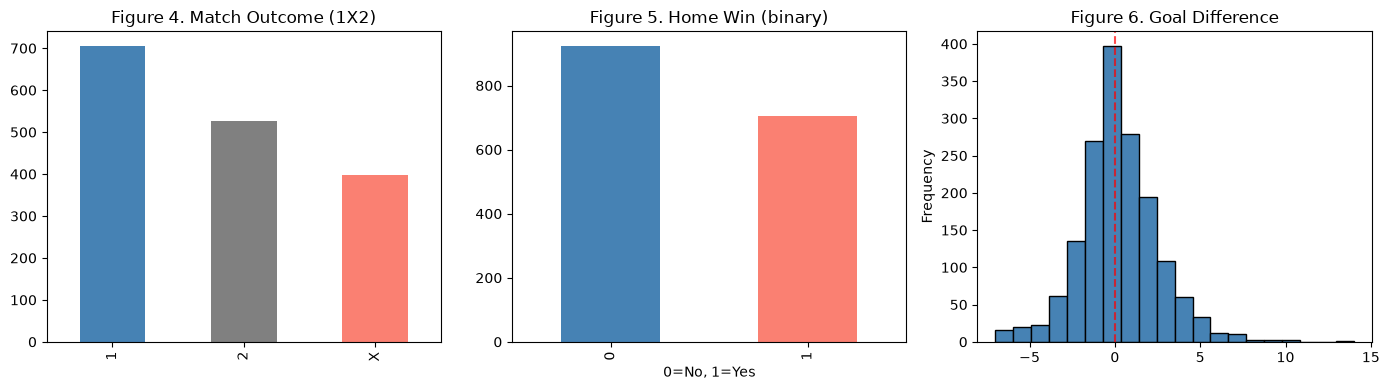

In [81]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Match outcome (1X2)
df['Result_1X2'].value_counts().plot(kind='bar', ax=axes[0], title='Figure 4. Match Outcome (1X2)', color=['steelblue','gray','salmon'])
axes[0].set_xlabel('')

# Home win
df['Home_Win'].value_counts().plot(kind='bar', ax=axes[1], title='Figure 5. Home Win (binary)', color=['steelblue','salmon'])
axes[1].set_xlabel('0=No, 1=Yes')

# Goal difference
df['Goals_diff'].plot(kind='hist', ax=axes[2], title='Figure 6. Goal Difference', bins=20, color='steelblue', edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


---
# Exploratory Data Analysis

The following analysis addresses the research question: **Which match performance statistics are the strongest predictors of football match outcomes?**

All figures use patterns (hatching, markers) to remain readable in black & white. Figures are numbered sequentially; tables are rounded to 3 decimal places.

### Table 2. Mean performance statistics by match outcome

Average values of key metric differences (Home − Away) grouped by match outcome (1 = home win, X = draw, 2 = away win). Positive values indicate a home team advantage.

In [ ]:
# --- Table 2: Mean stats by outcome ---
stats_cols = ['xG_diff', 'Possession_diff', 'Shots_on_Target_diff',
              'Corners_diff', 'Passes_Successful_diff', 'Saves_diff']
stats_cols = [c for c in stats_cols if c in df.columns]

table = df.groupby('Result_1X2')[stats_cols].mean().round(3)
table.index.name = 'Outcome'
table.index = table.index.map({'1': '1 (Home win)', 'X': 'X (Draw)', '2': '2 (Away win)'})
table.columns = [c.replace('_diff', '') for c in table.columns]
print('Table 2. Mean performance metric differences by match outcome')
print(table.to_string())

print('\nMatch counts per outcome:')
print(df['Result_1X2'].map({'1': '1 (Home win)', 'X': 'X (Draw)', '2': '2 (Away win)'}).value_counts().sort_index().to_string())

Table 2. Mean performance metric differences by match outcome
                 xG  Possession  Shots_on_Target  Corners  Passes_Successful  Saves
Outcome                                                                            
1 (Home win)  1.303      14.637            3.950    2.668            146.923 -1.698
2 (Away win) -0.935      -9.445           -2.833   -0.859            -98.244  0.980
X (Draw)      0.143       2.131            0.481    0.542             14.676 -0.495

Match counts per outcome:
Result_1X2
1 (Home win)    705
2 (Away win)    526
X (Draw)        397


### Figure 7. Distribution of key performance statistics by match outcome

Box plots of performance metric differences (Local − Visitante) grouped by match outcome. A systematic shift across groups indicates predictive power. The dashed line marks zero (parity between teams).

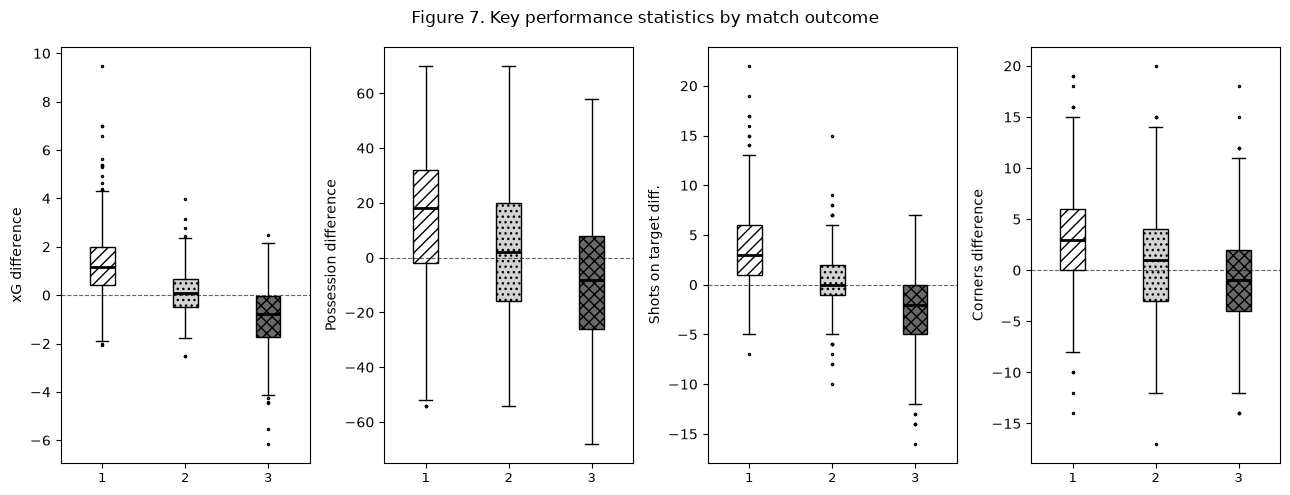

In [84]:
stats_plot = [
    ('xG_diff',           'xG difference'),
    ('Possession_diff',      'Possession difference'),
    ('Shots_on_Target_diff','Shots on target diff.'),
    ('Corners_diff',      'Corners difference'),
]
stats_plot = [(c, l) for c, l in stats_plot if c in df.columns]

outcomes = ['1', 'X', '2']
tick_labels = ['Home win\n(1)', 'Draw\n(X)', 'Away win\n(2)']
hatches = ['///', '...', 'xxx']
facecolors = ['white', 'lightgray', 'dimgray']

fig, axes = plt.subplots(1, len(stats_plot), figsize=(13, 5))
if len(stats_plot) == 1:
    axes = [axes]

for ax, (col, ylabel) in zip(axes, stats_plot):
    data_groups = [df.loc[df['Result_1X2'] == o, col].dropna() for o in outcomes]
    bp = ax.boxplot(data_groups, patch_artist=True, label=tick_labels,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', color='black', markersize=3))
    for patch, hatch, fc in zip(bp['boxes'], hatches, facecolors):
        patch.set_facecolor(fc)
        patch.set_hatch(hatch)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Figure 7. Key performance statistics by match outcome', fontsize=12)
plt.tight_layout()
plt.show()

### Figure 8. Correlation of match statistics with home team victory

Point-biserial correlation between each performance metric difference and the binary outcome Win\_Home(1 = home win, 0 = otherwise). Bars are ordered by absolute correlation, forward hatching (///) indicates positive association, back hatching (\\\\\\) indicates negative.

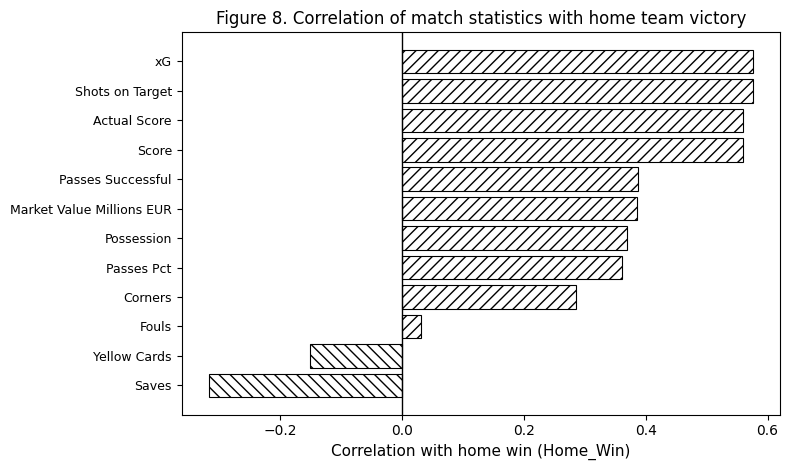

Top 5 predictors (absolute correlation):
xG_diff                   0.576
Shots_on_Target_diff      0.576
Score_diff                0.560
Actual_Score_diff         0.560
Passes_Successful_diff    0.388


In [ ]:
diff_cols = [c for c in df.columns if c.endswith('_diff')
             and c not in ('Goals_diff',) and df[c].dtype != object]
corrs = (df[diff_cols + ['Home_Win']]
         .corr(numeric_only=True)['Home_Win']
         .drop('Home_Win')
         .dropna()
         .sort_values())

fig, ax = plt.subplots(figsize=(8, max(4, len(corrs) * 0.4)))
bars = ax.barh(range(len(corrs)), corrs.values,
               color='white', edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, corrs.values):
    bar.set_hatch('///' if val >= 0 else '\\\\\\')

ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels([c.replace('_diff', '').replace('_', ' ') for c in corrs.index], fontsize=9)
ax.set_xlabel('Correlation with home win (Home_Win)', fontsize=11)
ax.set_title('Figure 8. Correlation of match statistics with home team victory', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 5 predictors (absolute correlation):')
print(corrs.abs().sort_values(ascending=False).head(5).round(3).to_string())

### Figure 9. Expected goals difference vs. goal difference

Scatter plot of xG difference against goal difference by match outcome. xG measures the quality of chances created; strong alignment with actual goals validates its use as a predictor. Outcomes are differentiated by marker shape to maintain B&W readability.

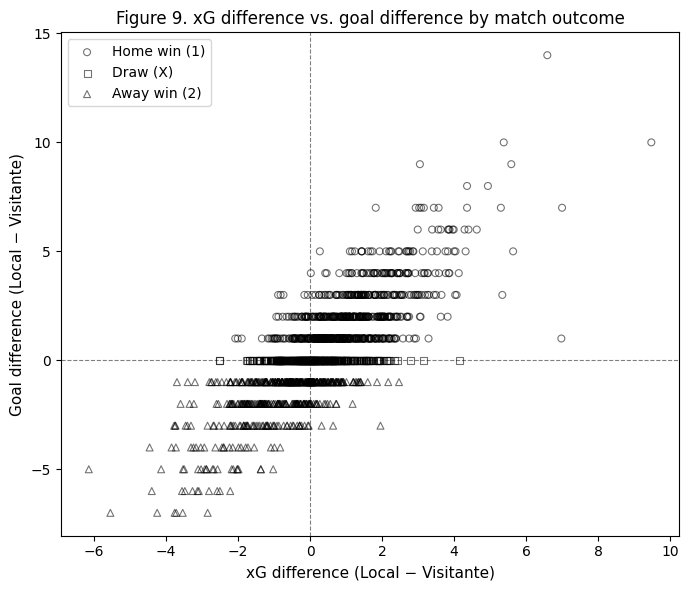

Pearson r (xG_diff vs Goals_diff): 0.782


In [ ]:
if 'xG_diff' in df.columns and 'Goals_diff' in df.columns:
    markers_map = {'1': 'o', 'X': 's', '2': '^'}
    labels_map  = {'1': 'Home win (1)', 'X': 'Draw (X)', '2': 'Away win (2)'}

    fig, ax = plt.subplots(figsize=(7, 6))
    for outcome, marker in markers_map.items():
        sub = df[df['Result_1X2'] == outcome].dropna(subset=['xG_diff', 'Goals_diff'])
        ax.scatter(sub['xG_diff'], sub['Goals_diff'],
                   marker=marker, s=25, alpha=0.55,
                   facecolors='none', edgecolors='black',
                   label=labels_map[outcome], linewidths=0.8)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('xG difference (Local − Visitante)', fontsize=11)
    ax.set_ylabel('Goal difference (Local − Visitante)', fontsize=11)
    ax.set_title('Figure 9. xG difference vs. goal difference by match outcome', fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    r = df[['xG_diff', 'Goals_diff']].corr().iloc[0, 1]
    print(f'Pearson r (xG_diff vs Goals_diff): {r:.3f}')

### Figure 10. Home win rate by xG difference quartile

Home win rate across quartiles of xG difference (Q1 = largest away advantage, Q4 = largest home advantage). A monotone increase across quartiles would confirm that xG is a reliable predictor of match outcome.

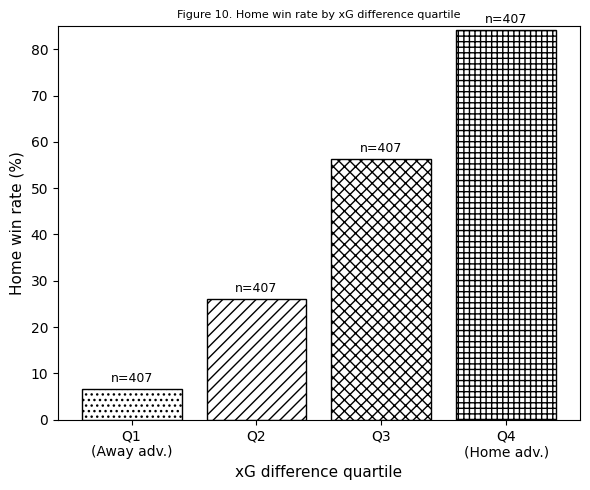

Table 3. Home win rate and match count by xG quartile
                 Win rate  Matches
xG_quartile                       
Q1\n(Away adv.)     0.066      407
Q2                  0.260      407
Q3                  0.563      407
Q4\n(Home adv.)     0.843      407


In [ ]:
if 'xG_diff' in df.columns:
    df_q = df[['xG_diff', 'Home_Win']].dropna().copy()
    df_q['xG_quartile'] = pd.qcut(df_q['xG_diff'], q=4,
                                   labels=['Q1\n(Away adv.)', 'Q2', 'Q3', 'Q4\n(Home adv.)'])
    wr = df_q.groupby('xG_quartile', observed=True)['Home_Win'].agg(['mean', 'count'])

    fig, ax = plt.subplots(figsize=(6, 5))
    hatches_q = ['...', '///', 'xxx', '+++']
    bars = ax.bar(range(len(wr)), wr['mean'] * 100,
                  color='white', edgecolor='black', linewidth=1)
    for bar, h in zip(bars, hatches_q):
        bar.set_hatch(h)
    for i, (rate, n) in enumerate(zip(wr['mean'], wr['count'])):
        ax.text(i, rate * 100 + 1.5, f'n={n}', ha='center', fontsize=9)

    ax.set_xticks(range(len(wr)))
    ax.set_xticklabels(wr.index, fontsize=10)
    ax.set_ylabel('Home win rate (%)', fontsize=11)
    ax.set_xlabel('xG difference quartile', fontsize=11)
    ax.set_title('Figure 10. Home win rate by xG difference quartile', fontsize=8)
    ax.set_ylim(0, 85)
    plt.tight_layout()
    plt.show()

    print('Table 3. Home win rate and match count by xG quartile')
    print(wr.rename(columns={'mean': 'Win rate', 'count': 'Matches'}).round(3).to_string())